## 0. Import & Setup

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Supaya output konsisten
import warnings
warnings.filterwarnings('ignore')

LANGUAGES = ['jav', 'min', 'sun']
LABEL_MAP = {0: 'negative', 2: 'positive'}
NUM_LABELS = 2

## 1. Load Dataset

In [16]:
datasets_per_lang = {}

for lang in LANGUAGES:
    dataset_name = f'nusatranslation_senti_{lang}_nusantara_text'
    datasets_per_lang[lang] = load_dataset(
        'indonlp/nusatranslation_senti',
        name=dataset_name,
        trust_remote_code=True
    )
    print(f"[{lang}] loaded: {datasets_per_lang[lang]}")

[jav] loaded: DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 3400
    })
    validation: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 448
    })
    test: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 1200
    })
})
[min] loaded: DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 3400
    })
    validation: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 448
    })
    test: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 1200
    })
})


Generating train split: 3400 examples [00:00, 30202.84 examples/s]
Generating validation split: 448 examples [00:00, 25463.43 examples/s]
Generating test split: 1200 examples [00:00, 30891.01 examples/s]


[sun] loaded: DatasetDict({
    train: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 3400
    })
    validation: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 448
    })
    test: Dataset({
        features: ['id', 'text', 'label'],
        num_rows: 1200
    })
})


#### Cek Struktur Data (Sample)

In [17]:
# Lihat satu sample dari masing-masing bahasa
for lang in LANGUAGES:
    sample = datasets_per_lang[lang]['train'][0]
    print(f"\n[{lang}] sample:")
    print(sample)


[jav] sample:
{'id': 'indolem-test-355', 'text': 'Bar dijawab dibusak, kanca modhel apa ? Aku nyekel hp sebelah iki http://ask.fm/a/bo26h59f ', 'label': 0}

[min] sample:
{'id': 'indolem-test-355', 'text': 'Abis dijawek diapuih,kawan macam apo ? Aden macik hp sabalah inj http://ask.fm/a/bo26h59f', 'label': 0}

[sun] sample:
{'id': 'indolem-test-355', 'text': 'Beres dijawab di hapus, babaturan siga naon ? Urang nyepeng HP sabeulah ieu http://ask.fm/a/bo26h59f ', 'label': 0}


## 2. EDA

#### Distribusi label per bahasa

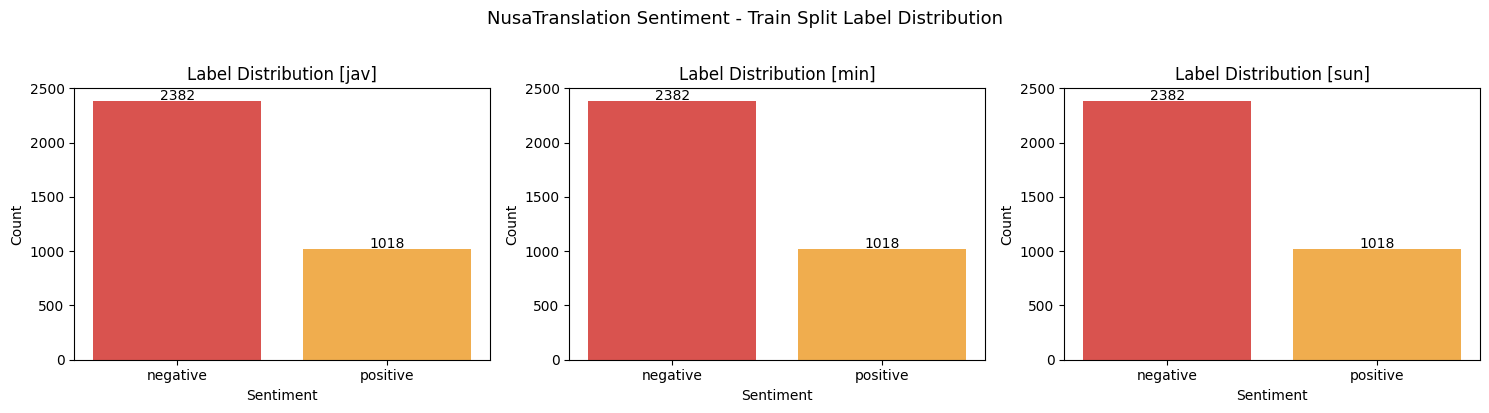

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, lang in enumerate(LANGUAGES):
    train_data = datasets_per_lang[lang]['train']
    df = pd.DataFrame(train_data)
    
    label_counts = df['label'].map(LABEL_MAP).value_counts()
    
    axes[idx].bar(label_counts.index, label_counts.values, 
                  color=['#d9534f', '#f0ad4e', '#5cb85c'])
    axes[idx].set_title(f'Label Distribution [{lang}]')
    axes[idx].set_xlabel('Sentiment')
    axes[idx].set_ylabel('Count')
    
    for i, (label, count) in enumerate(label_counts.items()):
        axes[idx].text(i, count + 10, str(count), ha='center', fontsize=10)

plt.suptitle('NusaTranslation Sentiment - Train Split Label Distribution', 
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

#### Distribusi panjang teks per bahasa

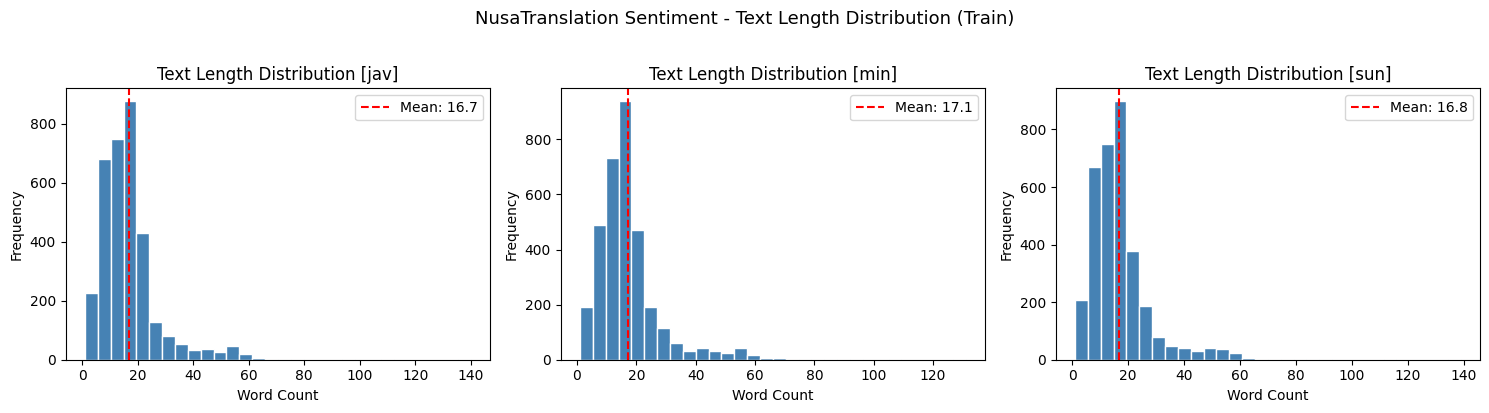

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, lang in enumerate(LANGUAGES):
    df = pd.DataFrame(datasets_per_lang[lang]['train'])
    df['text_length'] = df['text'].apply(lambda x: len(x.split()))
    
    axes[idx].hist(df['text_length'], bins=30, color='steelblue', edgecolor='white')
    axes[idx].set_title(f'Text Length Distribution [{lang}]')
    axes[idx].set_xlabel('Word Count')
    axes[idx].set_ylabel('Frequency')
    
    mean_len = df['text_length'].mean()
    axes[idx].axvline(mean_len, color='red', linestyle='--', 
                      label=f'Mean: {mean_len:.1f}')
    axes[idx].legend()

plt.suptitle('NusaTranslation Sentiment - Text Length Distribution (Train)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../results/text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Summary

In [20]:
summary = []

for lang in LANGUAGES:
    for split in ['train', 'validation', 'test']:
        df = pd.DataFrame(datasets_per_lang[lang][split])
        df['text_length'] = df['text'].apply(lambda x: len(x.split()))
        
        label_counts = df['label'].value_counts().to_dict()
        
        summary.append({
            'language': lang,
            'split': split,
            'total_samples': len(df),
            'negative (0)': label_counts.get(0, 0),
            'neutral (1)': label_counts.get(1, 0),
            'positive (2)': label_counts.get(2, 0),
            'avg_text_length': round(df['text_length'].mean(), 2),
            'max_text_length': df['text_length'].max(),
        })

summary_df = pd.DataFrame(summary)
summary_df.to_csv('../results/dataset_summary.csv', index=False)
print(summary_df.to_string(index=False))

language      split  total_samples  negative (0)  neutral (1)  positive (2)  avg_text_length  max_text_length
     jav      train           3400          2382            0          1018            16.73              140
     jav validation            448           333            0           115            16.44               67
     jav       test           1200           847            0           353            16.50              131
     min      train           3400          2382            0          1018            17.09              131
     min validation            448           333            0           115            16.74               63
     min       test           1200           847            0           353            16.82              135
     sun      train           3400          2382            0          1018            16.83              139
     sun validation            448           333            0           115            16.54               66
     sun  